In [1]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Proposed Method (Final Aligned Edition)
# 特点：Mean-Loss 聚合 | 动态权重 (10->5000) | 异构节点 Mask | 硬锚定 | +0.5236残差对齐
# 新增：BFS 纯物理死区掩码 N-1 推演 (Root=68)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random
import os
import warnings
from collections import deque

warnings.filterwarnings("ignore")

# ------------------------------------------
# 1. 环境配置与全局种子锁定
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 118节点主模型 (最终对齐版 + N-1推演) 启动 | 算力: {device}")

NUM_NODES = 118
obs_indices = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ------------------------------------------
# 2. 物理矩阵与节点身份掩码 (与消融实验 100% 对齐)
# ------------------------------------------
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_tensor = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_tensor = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

slack_buses = net.ext_grid.bus.values      # 索引 68
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(NUM_NODES)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(NUM_NODES)
mask_p_np[slack_buses] = 0.0

mask_q_np = np.zeros(NUM_NODES)
mask_q_np[load_buses] = 1.0
mask_q_np[zero_inj_buses] = 1.0

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ------------------------------------------
# 3. 模型与损失封装 (严格对齐：Mean-Loss + 硬锚定 + 0.5236残差)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    theta_rad = theta_pred * (np.pi / 180.0)
    dT = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=118):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        # 严格对齐主基线，118节点相角残差基准为 0.5236
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 0.005 + 0.5236     
        
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 68] = 1.0; theta_pred[:, 68] = 0.0      # 物理硬锚定绝不能丢！
        return vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, T_real, p_weight, obs_weight=5e6):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        
        diff_p = (P_calc - P_real) ** 2
        diff_q = (Q_calc - Q_real) ** 2
        bs = diff_p.shape[0]
        P_loss = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * bs)
        Q_loss = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * bs)
        
        obs_loss_v = self.mse(V_pred[:, self.obs_idx], V_real[:, self.obs_idx])
        obs_loss_t = self.mse(theta_pred[:, self.obs_idx], T_real[:, self.obs_idx])
        obs_loss = obs_loss_v + obs_loss_t
        
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.10)
        penalty = torch.mean(torch.pow(penalty_low, 2) + torch.pow(penalty_high, 2))
        
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 1e6 * penalty

def apply_blind_zone(batch_x, obs_idx_list, phys_zero):
    mask_bx = phys_zero.repeat(batch_x.shape[0], 1).to(device)
    for idx in obs_idx_list:
        mask_bx[:, idx] = batch_x[:, idx]                 
        mask_bx[:, idx+NUM_NODES] = batch_x[:, idx+NUM_NODES]  
    return mask_bx

# ------------------------------------------
# 4. 数据装载
# ------------------------------------------
print("📂 加载 118 节点数据...")
data_3d = np.load(r'ieee118_dataset/ieee118_data_50k.npy')
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

X_raw = np.concatenate([P_inj, Q_inj], axis=1)
Y_label = np.concatenate([V_val, T_rad], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_raw[:train_size], X_raw[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr_phys, Q_tr_phys = P_inj[:train_size], Q_inj[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

class GridDataset(Dataset):
    def __init__(self, x, y, p, q): self.x, self.y, self.p, self.q = x, y, p, q
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i], self.p[i], self.q[i]

train_loader = DataLoader(GridDataset(
    torch.tensor(X_tr_norm, dtype=torch.float32), torch.tensor(Y_tr, dtype=torch.float32),
    torch.tensor(P_tr_phys, dtype=torch.float32), torch.tensor(Q_tr_phys, dtype=torch.float32)), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练 (严格 300 轮动态课程学习)
# ------------------------------------------
model = PowerGridPINN(node_num=118).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
loss_fn = PowerPINNLoss(G_tensor, B_tensor, obs_indices)

print("🔥 开始 300 轮主干对齐训练...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000
    model.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = apply_blind_zone(bx, obs_indices, PHYS_ZERO)
        vp, tp = model(mask_bx)
        loss = loss_fn(vp, tp, bp, bq, by[:, :118], by[:, 118:], lambda_p, obs_weight=5e6)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 基态测试集评估
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
    ty = torch.tensor(Y_te, dtype=torch.float32).to(device)
    t_mask = apply_blind_zone(tx, obs_indices, PHYS_ZERO)
    v_pred_base, t_pred_base = model(t_mask)
    v_true_base = ty[:, :118]
    t_true_base = ty[:, 118:]
    
    err_v = (v_pred_base - v_true_base).cpu().numpy()
    err_t = (t_pred_base - t_true_base).cpu().numpy()
    v_mae = np.mean(np.abs(err_v))
    v_rmse = np.sqrt(np.mean(err_v**2))
    t_mae = np.mean(np.abs(err_t))
    t_rmse = np.sqrt(np.mean(err_t**2))

print("\n" + "="*60)
print(f"🏆 基态对账单 (Base Case)")
print(f"   Voltage MAE : {v_mae:.6e}  | RMSE : {v_rmse:.6e}")
print(f"   Phase Angle MAE : {t_mae:.6e}  | RMSE : {t_rmse:.6e}")
print("="*60)

# ------------------------------------------
# 7. BFS纯物理拓扑掩码 (修正 Root 为 68)
# ------------------------------------------
def get_topology_mask_118(G_np, B_np, cut_f, cut_t, num_nodes=118, root=68):
    """
    纯物理推导的 BFS 拓扑掩码（118节点版）
    切记：Python 0-base 索引下，118节点的平衡节点(Slack)是 68！
    """
    G_cut = G_np.copy()
    B_cut = B_np.copy()
    G_cut[cut_f, cut_t] = G_cut[cut_t, cut_f] = 0.0
    B_cut[cut_f, cut_t] = B_cut[cut_t, cut_f] = 0.0

    adj = (np.abs(G_cut) > 1e-6) | (np.abs(B_cut) > 1e-6)
    mask = np.zeros(num_nodes, dtype=np.float32)
    q = deque([root])
    mask[root] = 1.0
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0:
                mask[v] = 1.0
                q.append(v)
    return mask, torch.tensor(mask, dtype=torch.float32).to(device)

# ------------------------------------------
# 8. N-1 Zero-shot 推演（纯物理掩码，无数据泄漏）
# ------------------------------------------
test_cases = [
    {"n": "C1", "file": "ieee118_C1_1k.npy", "cut": (10, 11)},   # Bus 11-12
    {"n": "C2", "file": "ieee118_C2_1k.npy", "cut": (22, 23)},   # Bus 23-24
    {"n": "C3", "file": "ieee118_C3_1k.npy", "cut": (53, 55)}    # Bus 54-56
]

print("\n⚔️ N-1 Zero-shot 推演 (纯物理 BFS 掩码，无数据泄漏)")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(118)

with torch.no_grad():
    for case in test_cases:
        if not os.path.exists(f"ieee118_dataset/{case['file']}"):
            print(f"⚠️ 找不到文件 {case['file']}，跳过 {case['n']} 推演。")
            continue
            
        data_n1 = np.load(f"ieee118_dataset/{case['file']}")
        
        # 数据预处理必须与训练集一致
        P_n1 = -data_n1[:, :, 0] / 100.0  
        Q_n1 = -data_n1[:, :, 1] / 100.0
        X_raw_n1 = np.concatenate([P_n1, Q_n1], axis=1)
        X_n1_norm = scaler.transform(X_raw_n1)
        
        X_n1_tensor = torch.tensor(X_n1_norm, dtype=torch.float32).to(device)
        V_true_n1 = data_n1[:, :, 2]
        T_true_n1 = np.deg2rad(data_n1[:, :, 3])

        V_pred_n1, T_pred_n1 = model(apply_blind_zone(X_n1_tensor, obs_indices, PHYS_ZERO))
        V_pred_np = V_pred_n1.cpu().numpy()
        T_pred_np = T_pred_n1.cpu().numpy()

        # ✅ 纯物理 BFS 掩码，只评估连通的活区
        cut_f, cut_t = case["cut"]
        mask_np, _ = get_topology_mask_118(G_tensor.cpu().numpy(), B_tensor.cpu().numpy(), cut_f, cut_t, root=68)
        mask = mask_np.reshape(1, -1)

        V_pred_masked = V_pred_np * mask
        V_true_masked = V_true_n1 * mask
        T_pred_masked = T_pred_np * mask
        T_true_masked = T_true_n1 * mask

        err_v = (V_pred_masked - V_true_masked).ravel()
        err_t = (T_pred_masked - T_true_masked).ravel()
        active_nodes = np.sum(mask_np)
        dead = np.where(mask_np == 0)[0]

        mae_v = np.sum(np.abs(err_v)) / (active_nodes * len(V_true_n1))
        rmse_v = np.sqrt(np.sum(err_v**2) / (active_nodes * len(V_true_n1)))
        mae_t = np.sum(np.abs(err_t)) / (active_nodes * len(V_true_n1))
        rmse_t = np.sqrt(np.sum(err_t**2) / (active_nodes * len(V_true_n1)))

        print(f"\n🔬 {case['n']} | 断开支路: {cut_f}-{cut_t} | 死区节点数: {len(dead)}")
        print(f"   V  MAE: {mae_v:.6e}  RMSE: {rmse_v:.6e}")
        print(f"   θ  MAE: {mae_t:.6e}  RMSE: {rmse_t:.6e}")

        # ---------------- 绘图 ----------------
        sid = 10
        v_t_sample = V_true_n1[sid] * mask_np
        v_p_sample = V_pred_np[sid] * mask_np
        t_t_sample = T_true_n1[sid] * mask_np
        t_p_sample = T_pred_np[sid] * mask_np
        
        # 将死区画成 NaN 以便在图中断开显示，更符合真实物理观感
        v_t_plot = np.where(mask_np == 1, v_t_sample, np.nan)
        v_p_plot = np.where(mask_np == 1, v_p_sample, np.nan)
        t_t_plot = np.where(mask_np == 1, t_t_sample, np.nan)
        t_p_plot = np.where(mask_np == 1, t_p_sample, np.nan)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)
        ax1.axvspan(0, 117, color='gray', alpha=0.05)
        ax1.plot(nodes, v_t_plot, 'k-', label='Ground Truth (Active)', linewidth=2.0)
        ax1.plot(nodes, v_p_plot, 'r--', label='Proposed R-PINN (Active)', linewidth=1.5)
        ax1.scatter(obs_indices, v_t_plot[obs_indices], color='blue', marker='*', s=150, label='PMU Sensors')
        ax1.set_title(f'N-1 Case {case["n"]}: (a) Voltage Magnitude', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Voltage (p.u.)', fontsize=12)
        ax1.legend(loc='lower left', fontsize=11); ax1.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax1.axvline(d, color='red', alpha=0.15, linewidth=4)

        ax2.axvspan(0, 117, color='gray', alpha=0.05)
        ax2.plot(nodes, t_t_plot, 'k-', linewidth=2.0)
        ax2.plot(nodes, t_p_plot, 'b--', label='Proposed R-PINN (Active)', linewidth=1.5)
        ax2.scatter(obs_indices, t_t_plot[obs_indices], color='blue', marker='*', s=150)
        ax2.set_title('(b) Phase Angle', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Bus Index', fontsize=12); ax2.set_ylabel('Phase Angle (rad)', fontsize=12)
        ax2.set_xlim(0, 117); ax2.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax2.axvline(d, color='red', alpha=0.15, linewidth=4)

        plt.tight_layout()
        plt.savefig(f'ieee118_n1_{case["n"]}_aligned.png', bbox_inches='tight', dpi=600)

print("\n✅ 代码已彻底洗净并封装完毕！所有消融实验变量现已处于绝对控制之下。")

🚀 118节点主模型 (Proposed R-PINN) 全量审计启动 | 算力: cuda
📥 加载 50k 基态数据并执行 PSC 对齐...
🔥 启动 600 轮基态极致重构训练 (节点 Mask + 动态 Curriculum)...


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# 🏆 IEEE 118-Bus Ablation Case 1: Sum-Loss Strategy (Final Aligned Edition)
# 变量控制：【保留】300轮动态权重、硬锚定、+0.5236残差、异构节点Mask、BFS纯物理推演
# 变量控制：【修改】仅将观测损失 (Obs Loss) 的聚合方式从 Mean 替换为 Sum，证明梯度量级差异
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random
import os
import warnings
from collections import deque

warnings.filterwarnings("ignore")

# ------------------------------------------
# 1. 环境配置与全局种子锁定 (严格对齐)
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 118节点消融实验 (Sum-Loss 公平对齐版) 启动 | 算力: {device}")

NUM_NODES = 118
obs_indices = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ------------------------------------------
# 2. 物理矩阵与节点身份掩码 (严格对齐)
# ------------------------------------------
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_tensor = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_tensor = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

slack_buses = net.ext_grid.bus.values      # 索引 68
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(NUM_NODES)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(NUM_NODES)
mask_p_np[slack_buses] = 0.0

mask_q_np = np.zeros(NUM_NODES)
mask_q_np[load_buses] = 1.0
mask_q_np[zero_inj_buses] = 1.0

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ------------------------------------------
# 3. 模型与损失封装 (唯一剥离点：Sum-Loss)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    theta_rad = theta_pred * (np.pi / 180.0)
    dT = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=118):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        # 严格对齐起跑线与物理锚定
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 0.005 + 0.5236     
        
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 68] = 1.0; theta_pred[:, 68] = 0.0      
        return vm_pred, theta_pred

class PowerPINNLoss_SumAblation(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss_SumAblation, self).__init__()
        self.G = G; self.B = B; self.obs_idx = obs_idx

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, T_real, p_weight, obs_weight=5e6):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        
        diff_p = (P_calc - P_real) ** 2
        diff_q = (Q_calc - Q_real) ** 2
        bs = diff_p.shape[0]
        P_loss = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * bs)
        Q_loss = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * bs)
        
        # 👑 【核心修改点】：这里将 MSE (Mean) 改为纯粹的 Sum 累加！
        # 为了防范梯度爆炸并维持与主实验同等的相对惩罚力度，这里需除以传感器数量（或在外部降低 obs_weight）
        # 这里严格复刻你的思路：用 Sum 算完后，给一个等比的 fair_weight
        obs_loss_v = torch.sum((V_pred[:, self.obs_idx] - V_real[:, self.obs_idx])**2)
        obs_loss_t = torch.sum((theta_pred[:, self.obs_idx] - T_real[:, self.obs_idx])**2)
        obs_loss = obs_loss_v + obs_loss_t
        fair_obs_weight = obs_weight / len(self.obs_idx)
        
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.10)
        penalty = torch.mean(torch.pow(penalty_low, 2) + torch.pow(penalty_high, 2))
        
        return p_weight * (P_loss + Q_loss) + fair_obs_weight * obs_loss + 1e6 * penalty

def apply_blind_zone(batch_x, obs_idx_list, phys_zero):
    mask_bx = phys_zero.repeat(batch_x.shape[0], 1).to(device)
    for idx in obs_idx_list:
        mask_bx[:, idx] = batch_x[:, idx]                 
        mask_bx[:, idx+NUM_NODES] = batch_x[:, idx+NUM_NODES]  
    return mask_bx

# ------------------------------------------
# 4. 数据装载 (严格对齐)
# ------------------------------------------
print("📂 加载 118 节点数据...")
data_3d = np.load(r'ieee118_dataset/ieee118_data_50k.npy')
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

X_raw = np.concatenate([P_inj, Q_inj], axis=1)
Y_label = np.concatenate([V_val, T_rad], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_raw[:train_size], X_raw[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr_phys, Q_tr_phys = P_inj[:train_size], Q_inj[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

class GridDataset(Dataset):
    def __init__(self, x, y, p, q): self.x, self.y, self.p, self.q = x, y, p, q
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i], self.p[i], self.q[i]

train_loader = DataLoader(GridDataset(
    torch.tensor(X_tr_norm, dtype=torch.float32), torch.tensor(Y_tr, dtype=torch.float32),
    torch.tensor(P_tr_phys, dtype=torch.float32), torch.tensor(Q_tr_phys, dtype=torch.float32)), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练 (严格 300 轮动态课程学习对齐)
# ------------------------------------------
model = PowerGridPINN(node_num=118).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
loss_fn = PowerPINNLoss_SumAblation(G_tensor, B_tensor, obs_indices)

print("🔥 开始 300 轮消融组对齐训练 (Sum-Loss 模式)...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000
    model.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = apply_blind_zone(bx, obs_indices, PHYS_ZERO)
        vp, tp = model(mask_bx)
        loss = loss_fn(vp, tp, bp, bq, by[:, :118], by[:, 118:], lambda_p, obs_weight=5e6)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 基态测试集评估
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
    ty = torch.tensor(Y_te, dtype=torch.float32).to(device)
    t_mask = apply_blind_zone(tx, obs_indices, PHYS_ZERO)
    v_pred_base, t_pred_base = model(t_mask)
    v_true_base = ty[:, :118]
    t_true_base = ty[:, 118:]
    
    err_v = (v_pred_base - v_true_base).cpu().numpy()
    err_t = (t_pred_base - t_true_base).cpu().numpy()
    v_mae = np.mean(np.abs(err_v))
    v_rmse = np.sqrt(np.mean(err_v**2))
    t_mae = np.mean(np.abs(err_t))
    t_rmse = np.sqrt(np.mean(err_t**2))

print("\n" + "="*60)
print(f"🏆 基态对账单 (Ablation: Sum-Loss)")
print(f"   Voltage MAE : {v_mae:.6e}  | RMSE : {v_rmse:.6e}")
print(f"   Phase Angle MAE : {t_mae:.6e}  | RMSE : {t_rmse:.6e}")
print("="*60)

# ------------------------------------------
# 7. BFS纯物理拓扑掩码 (严格修正 Root=68)
# ------------------------------------------
def get_topology_mask_118(G_np, B_np, cut_f, cut_t, num_nodes=118, root=68):
    G_cut = G_np.copy()
    B_cut = B_np.copy()
    G_cut[cut_f, cut_t] = G_cut[cut_t, cut_f] = 0.0
    B_cut[cut_f, cut_t] = B_cut[cut_t, cut_f] = 0.0

    adj = (np.abs(G_cut) > 1e-6) | (np.abs(B_cut) > 1e-6)
    mask = np.zeros(num_nodes, dtype=np.float32)
    q = deque([root])
    mask[root] = 1.0
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0:
                mask[v] = 1.0
                q.append(v)
    return mask, torch.tensor(mask, dtype=torch.float32).to(device)

# ------------------------------------------
# 8. N-1 Zero-shot 推演 (NaN处理，完美画图)
# ------------------------------------------
test_cases = [
    {"n": "C1", "file": "ieee118_C1_1k.npy", "cut": (10, 11)},   # Bus 11-12
    {"n": "C2", "file": "ieee118_C2_1k.npy", "cut": (22, 23)},   # Bus 23-24
    {"n": "C3", "file": "ieee118_C3_1k.npy", "cut": (53, 55)}    # Bus 54-56
]

print("\n⚔️ N-1 Zero-shot 推演 (纯物理 BFS 掩码，Sum-Loss 模式)")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(118)

with torch.no_grad():
    for case in test_cases:
        if not os.path.exists(f"ieee118_dataset/{case['file']}"):
            print(f"⚠️ 找不到文件 {case['file']}，跳过 {case['n']} 推演。")
            continue
            
        data_n1 = np.load(f"ieee118_dataset/{case['file']}")
        
        P_n1 = -data_n1[:, :, 0] / 100.0  
        Q_n1 = -data_n1[:, :, 1] / 100.0
        X_raw_n1 = np.concatenate([P_n1, Q_n1], axis=1)
        X_n1_norm = scaler.transform(X_raw_n1)
        
        X_n1_tensor = torch.tensor(X_n1_norm, dtype=torch.float32).to(device)
        V_true_n1 = data_n1[:, :, 2]
        T_true_n1 = np.deg2rad(data_n1[:, :, 3])

        V_pred_n1, T_pred_n1 = model(apply_blind_zone(X_n1_tensor, obs_indices, PHYS_ZERO))
        V_pred_np = V_pred_n1.cpu().numpy()
        T_pred_np = T_pred_n1.cpu().numpy()

        cut_f, cut_t = case["cut"]
        mask_np, _ = get_topology_mask_118(G_tensor.cpu().numpy(), B_tensor.cpu().numpy(), cut_f, cut_t, root=68)
        mask = mask_np.reshape(1, -1)

        V_pred_masked = V_pred_np * mask
        V_true_masked = V_true_n1 * mask
        T_pred_masked = T_pred_np * mask
        T_true_masked = T_true_n1 * mask

        err_v = (V_pred_masked - V_true_masked).ravel()
        err_t = (T_pred_masked - T_true_masked).ravel()
        active_nodes = np.sum(mask_np)
        dead = np.where(mask_np == 0)[0]

        mae_v = np.sum(np.abs(err_v)) / (active_nodes * len(V_true_n1))
        rmse_v = np.sqrt(np.sum(err_v**2) / (active_nodes * len(V_true_n1)))
        mae_t = np.sum(np.abs(err_t)) / (active_nodes * len(V_true_n1))
        rmse_t = np.sqrt(np.sum(err_t**2) / (active_nodes * len(V_true_n1)))

        print(f"\n🔬 {case['n']} | 断开支路: {cut_f}-{cut_t} | 死区节点数: {len(dead)}")
        print(f"   V  MAE: {mae_v:.6e}  RMSE: {rmse_v:.6e}")
        print(f"   θ  MAE: {mae_t:.6e}  RMSE: {rmse_t:.6e}")

        # ---------------- 绘图 (带 NaN 断线处理) ----------------
        sid = 10
        v_t_sample = V_true_n1[sid] * mask_np
        v_p_sample = V_pred_np[sid] * mask_np
        t_t_sample = T_true_n1[sid] * mask_np
        t_p_sample = T_pred_np[sid] * mask_np
        
        v_t_plot = np.where(mask_np == 1, v_t_sample, np.nan)
        v_p_plot = np.where(mask_np == 1, v_p_sample, np.nan)
        t_t_plot = np.where(mask_np == 1, t_t_sample, np.nan)
        t_p_plot = np.where(mask_np == 1, t_p_sample, np.nan)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)
        ax1.axvspan(0, 117, color='gray', alpha=0.05)
        ax1.plot(nodes, v_t_plot, 'k-', label='Ground Truth (Active)', linewidth=2.0)
        ax1.plot(nodes, v_p_plot, 'r--', label='Ablation PINN: Sum-Loss (Active)', linewidth=1.5)
        ax1.scatter(obs_indices, v_t_plot[obs_indices], color='blue', marker='*', s=150, label='PMU Sensors')
        ax1.set_title(f'N-1 Case {case["n"]} (Sum-Loss Ablation): (a) Voltage Magnitude', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Voltage (p.u.)', fontsize=12)
        ax1.legend(loc='lower left', fontsize=11); ax1.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax1.axvline(d, color='red', alpha=0.15, linewidth=4)

        ax2.axvspan(0, 117, color='gray', alpha=0.05)
        ax2.plot(nodes, t_t_plot, 'k-', linewidth=2.0)
        ax2.plot(nodes, t_p_plot, 'b--', label='Ablation PINN: Sum-Loss (Active)', linewidth=1.5)
        ax2.scatter(obs_indices, t_t_plot[obs_indices], color='blue', marker='*', s=150)
        ax2.set_title('(b) Phase Angle', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Bus Index', fontsize=12); ax2.set_ylabel('Phase Angle (rad)', fontsize=12)
        ax2.set_xlim(0, 117); ax2.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax2.axvline(d, color='red', alpha=0.15, linewidth=4)

        plt.tight_layout()
        plt.savefig(f'ieee118_n1_{case["n"]}_sum_aligned.png', bbox_inches='tight', dpi=600)

print("\n✅ Sum-Loss 消融代码已完美嵌入主干框架！")

In [2]:
# ==============================================================================
# 🏆 IEEE 118-Bus Ablation Case 2: No-ARS Strategy (Final Aligned Edition)
# 变量控制：【保留】300轮动态权重、硬锚定、异构节点Mask、Mean-Loss、BFS纯物理推演
# 变量控制：【修改】剥离 ARS (Asymmetric Residual Scaling)，使用基础 Sigmoid 替代先验映射
# 修复警告：彻底清除了原草稿中 N-1 测试集依赖 V_true_n1 < 1e-3 的数据泄漏！
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random
import os
import warnings
from collections import deque

warnings.filterwarnings("ignore")

# ------------------------------------------
# 1. 环境配置与全局种子锁定 (严格对齐)
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 118节点消融实验 (No-ARS 公平对齐版) 启动 | 算力: {device}")

NUM_NODES = 118
obs_indices = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ------------------------------------------
# 2. 物理矩阵与节点身份掩码 (严格对齐)
# ------------------------------------------
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_tensor = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_tensor = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

slack_buses = net.ext_grid.bus.values      # 索引 68
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(NUM_NODES)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(NUM_NODES)
mask_p_np[slack_buses] = 0.0

mask_q_np = np.zeros(NUM_NODES)
mask_q_np[load_buses] = 1.0
mask_q_np[zero_inj_buses] = 1.0

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ------------------------------------------
# 3. 模型与损失封装 (唯一剥离点：移除 ARS)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    theta_rad = theta_pred * (np.pi / 180.0)
    dT = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

class PowerGridPINN_NoARS(nn.Module):
    def __init__(self, node_num=118):
        super(PowerGridPINN_NoARS, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        
        # 👑 【核心修改点】：移除 ARS 先验映射，使用盲目的基础激活
        # 电压不再围绕 1.0 微调，相角不再围绕 0.5236 微调
        vm_pred = torch.sigmoid(out[:, :self.node_num]) * 1.2  
        theta_pred = out[:, self.node_num:] * 1.0     
        
        # ⚠️ 但物理法则的基石不能丢：Slack Bus 必须硬锚定
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 68] = 1.0; theta_pred[:, 68] = 0.0      
        return vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, T_real, p_weight, obs_weight=5e6):
        # 完美对齐主基线的 Mean-Loss
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        
        diff_p = (P_calc - P_real) ** 2
        diff_q = (Q_calc - Q_real) ** 2
        bs = diff_p.shape[0]
        P_loss = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * bs)
        Q_loss = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * bs)
        
        obs_loss_v = self.mse(V_pred[:, self.obs_idx], V_real[:, self.obs_idx])
        obs_loss_t = self.mse(theta_pred[:, self.obs_idx], T_real[:, self.obs_idx])
        obs_loss = obs_loss_v + obs_loss_t
        
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.10)
        penalty = torch.mean(torch.pow(penalty_low, 2) + torch.pow(penalty_high, 2))
        
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 1e6 * penalty

def apply_blind_zone(batch_x, obs_idx_list, phys_zero):
    mask_bx = phys_zero.repeat(batch_x.shape[0], 1).to(device)
    for idx in obs_idx_list:
        mask_bx[:, idx] = batch_x[:, idx]                 
        mask_bx[:, idx+NUM_NODES] = batch_x[:, idx+NUM_NODES]  
    return mask_bx

# ------------------------------------------
# 4. 数据装载 (严格对齐)
# ------------------------------------------
print("📂 加载 118 节点数据...")
data_3d = np.load(r'ieee118_dataset/ieee118_data_50k.npy')
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

X_raw = np.concatenate([P_inj, Q_inj], axis=1)
Y_label = np.concatenate([V_val, T_rad], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_raw[:train_size], X_raw[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr_phys, Q_tr_phys = P_inj[:train_size], Q_inj[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

class GridDataset(Dataset):
    def __init__(self, x, y, p, q): self.x, self.y, self.p, self.q = x, y, p, q
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i], self.p[i], self.q[i]

train_loader = DataLoader(GridDataset(
    torch.tensor(X_tr_norm, dtype=torch.float32), torch.tensor(Y_tr, dtype=torch.float32),
    torch.tensor(P_tr_phys, dtype=torch.float32), torch.tensor(Q_tr_phys, dtype=torch.float32)), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练 (严格 300 轮动态课程学习对齐)
# ------------------------------------------
model = PowerGridPINN_NoARS(node_num=118).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
loss_fn = PowerPINNLoss(G_tensor, B_tensor, obs_indices)

print("🔥 开始 300 轮消融组对齐训练 (No-ARS 模式)...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000
    model.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = apply_blind_zone(bx, obs_indices, PHYS_ZERO)
        vp, tp = model(mask_bx)
        loss = loss_fn(vp, tp, bp, bq, by[:, :118], by[:, 118:], lambda_p, obs_weight=5e6)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 基态测试集评估
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
    ty = torch.tensor(Y_te, dtype=torch.float32).to(device)
    t_mask = apply_blind_zone(tx, obs_indices, PHYS_ZERO)
    v_pred_base, t_pred_base = model(t_mask)
    v_true_base = ty[:, :118]
    t_true_base = ty[:, 118:]
    
    err_v = (v_pred_base - v_true_base).cpu().numpy()
    err_t = (t_pred_base - t_true_base).cpu().numpy()
    v_mae = np.mean(np.abs(err_v))
    v_rmse = np.sqrt(np.mean(err_v**2))
    t_mae = np.mean(np.abs(err_t))
    t_rmse = np.sqrt(np.mean(err_t**2))

print("\n" + "="*60)
print(f"🏆 基态对账单 (Ablation: No-ARS)")
print(f"   Voltage MAE : {v_mae:.6e}  | RMSE : {v_rmse:.6e}")
print(f"   Phase Angle MAE : {t_mae:.6e}  | RMSE : {t_rmse:.6e}")
print("="*60)

# ------------------------------------------
# 7. BFS纯物理拓扑掩码 (严格修正 Root=68，杜绝数据泄漏)
# ------------------------------------------
def get_topology_mask_118(G_np, B_np, cut_f, cut_t, num_nodes=118, root=68):
    G_cut = G_np.copy()
    B_cut = B_np.copy()
    G_cut[cut_f, cut_t] = G_cut[cut_t, cut_f] = 0.0
    B_cut[cut_f, cut_t] = B_cut[cut_t, cut_f] = 0.0

    adj = (np.abs(G_cut) > 1e-6) | (np.abs(B_cut) > 1e-6)
    mask = np.zeros(num_nodes, dtype=np.float32)
    q = deque([root])
    mask[root] = 1.0
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0:
                mask[v] = 1.0
                q.append(v)
    return mask, torch.tensor(mask, dtype=torch.float32).to(device)

# ------------------------------------------
# 8. N-1 Zero-shot 推演 (完美控制，NaN处理)
# ------------------------------------------
test_cases = [
    {"n": "C1", "file": "ieee118_C1_1k.npy", "cut": (10, 11)},   # Bus 11-12
    {"n": "C2", "file": "ieee118_C2_1k.npy", "cut": (22, 23)},   # Bus 23-24
    {"n": "C3", "file": "ieee118_C3_1k.npy", "cut": (53, 55)}    # Bus 54-56
]

print("\n⚔️ N-1 Zero-shot 推演 (纯物理 BFS 掩码，No-ARS 模式)")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(118)

with torch.no_grad():
    for case in test_cases:
        if not os.path.exists(f"ieee118_dataset/{case['file']}"):
            print(f"⚠️ 找不到文件 {case['file']}，跳过 {case['n']} 推演。")
            continue
            
        data_n1 = np.load(f"ieee118_dataset/{case['file']}")
        
        P_n1 = -data_n1[:, :, 0] / 100.0  
        Q_n1 = -data_n1[:, :, 1] / 100.0
        X_raw_n1 = np.concatenate([P_n1, Q_n1], axis=1)
        X_n1_norm = scaler.transform(X_raw_n1)
        
        X_n1_tensor = torch.tensor(X_n1_norm, dtype=torch.float32).to(device)
        V_true_n1 = data_n1[:, :, 2]
        T_true_n1 = np.deg2rad(data_n1[:, :, 3])

        V_pred_n1, T_pred_n1 = model(apply_blind_zone(X_n1_tensor, obs_indices, PHYS_ZERO))
        V_pred_np = V_pred_n1.cpu().numpy()
        T_pred_np = T_pred_n1.cpu().numpy()

        # 👑 绝对无泄漏的 BFS 掩码生成
        cut_f, cut_t = case["cut"]
        mask_np, _ = get_topology_mask_118(G_tensor.cpu().numpy(), B_tensor.cpu().numpy(), cut_f, cut_t, root=68)
        mask = mask_np.reshape(1, -1)

        V_pred_masked = V_pred_np * mask
        V_true_masked = V_true_n1 * mask
        T_pred_masked = T_pred_np * mask
        T_true_masked = T_true_n1 * mask

        err_v = (V_pred_masked - V_true_masked).ravel()
        err_t = (T_pred_masked - T_true_masked).ravel()
        active_nodes = np.sum(mask_np)
        dead = np.where(mask_np == 0)[0]

        mae_v = np.sum(np.abs(err_v)) / (active_nodes * len(V_true_n1))
        rmse_v = np.sqrt(np.sum(err_v**2) / (active_nodes * len(V_true_n1)))
        mae_t = np.sum(np.abs(err_t)) / (active_nodes * len(V_true_n1))
        rmse_t = np.sqrt(np.sum(err_t**2) / (active_nodes * len(V_true_n1)))

        print(f"\n🔬 {case['n']} | 断开支路: {cut_f}-{cut_t} | 死区节点数: {len(dead)}")
        print(f"   V  MAE: {mae_v:.6e}  RMSE: {rmse_v:.6e}")
        print(f"   θ  MAE: {mae_t:.6e}  RMSE: {rmse_t:.6e}")

        # ---------------- 绘图 (带 NaN 断线处理) ----------------
        sid = 10
        v_t_sample = V_true_n1[sid] * mask_np
        v_p_sample = V_pred_np[sid] * mask_np
        t_t_sample = T_true_n1[sid] * mask_np
        t_p_sample = T_pred_np[sid] * mask_np
        
        v_t_plot = np.where(mask_np == 1, v_t_sample, np.nan)
        v_p_plot = np.where(mask_np == 1, v_p_sample, np.nan)
        t_t_plot = np.where(mask_np == 1, t_t_sample, np.nan)
        t_p_plot = np.where(mask_np == 1, t_p_sample, np.nan)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)
        ax1.axvspan(0, 117, color='gray', alpha=0.05)
        ax1.plot(nodes, v_t_plot, 'k-', label='Ground Truth (Active)', linewidth=2.0)
        ax1.plot(nodes, v_p_plot, 'r--', label='Ablation PINN: No-ARS (Active)', linewidth=1.5)
        ax1.scatter(obs_indices, v_t_plot[obs_indices], color='blue', marker='*', s=150, label='PMU Sensors')
        ax1.set_title(f'N-1 Case {case["n"]} (No-ARS Ablation): (a) Voltage Magnitude', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Voltage (p.u.)', fontsize=12)
        ax1.legend(loc='lower left', fontsize=11); ax1.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax1.axvline(d, color='red', alpha=0.15, linewidth=4)

        ax2.axvspan(0, 117, color='gray', alpha=0.05)
        ax2.plot(nodes, t_t_plot, 'k-', linewidth=2.0)
        ax2.plot(nodes, t_p_plot, 'b--', label='Ablation PINN: No-ARS (Active)', linewidth=1.5)
        ax2.scatter(obs_indices, t_t_plot[obs_indices], color='blue', marker='*', s=150)
        ax2.set_title('(b) Phase Angle', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Bus Index', fontsize=12); ax2.set_ylabel('Phase Angle (rad)', fontsize=12)
        ax2.set_xlim(0, 117); ax2.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax2.axvline(d, color='red', alpha=0.15, linewidth=4)

        plt.tight_layout()
        plt.savefig(f'ieee118_n1_{case["n"]}_noars_aligned.png', bbox_inches='tight', dpi=600)

print("\n✅ No-ARS 消融代码已完美嵌入主干框架，数据泄漏雷点已彻底清除！干！")

🚀 118节点 No-ARS 消融舱点火 | 算力: cuda | 模式: Mean-Loss
📥 装载 118 节点 50k 物理样本...
🔥 开始 600 轮 No-ARS 消融组训练...


KeyboardInterrupt: 

🚀 118节点小样本实验启动 (5k训练数据) | 算力: cuda | 模式: Proposed Mean-Loss
📥 执行 5k 少样本切片并在 Float32 空间压铸...
🔥 启动 600 轮小样本 (5k) 重构战役... 测试集规模: 45000
Epoch 100 | Loss: 7.2442e+02 | LR: 5.00e-04
Epoch 200 | Loss: 6.8675e+02 | LR: 1.25e-04
Epoch 300 | Loss: 6.8043e+02 | LR: 3.13e-05
Epoch 400 | Loss: 6.8101e+02 | LR: 7.81e-06
Epoch 500 | Loss: 6.8119e+02 | LR: 2.44e-07
Epoch 600 | Loss: 6.8285e+02 | LR: 1.53e-08

==================== [Base Case Audit: 5k Few-Shot] ====================
🏆 IEEE 118-Bus Few-Shot (5k) Statistics (on 45k Test Samples):
   Overall MAE : 4.483697e-03 p.u.
   Overall RMSE: 6.509023e-03 p.u.


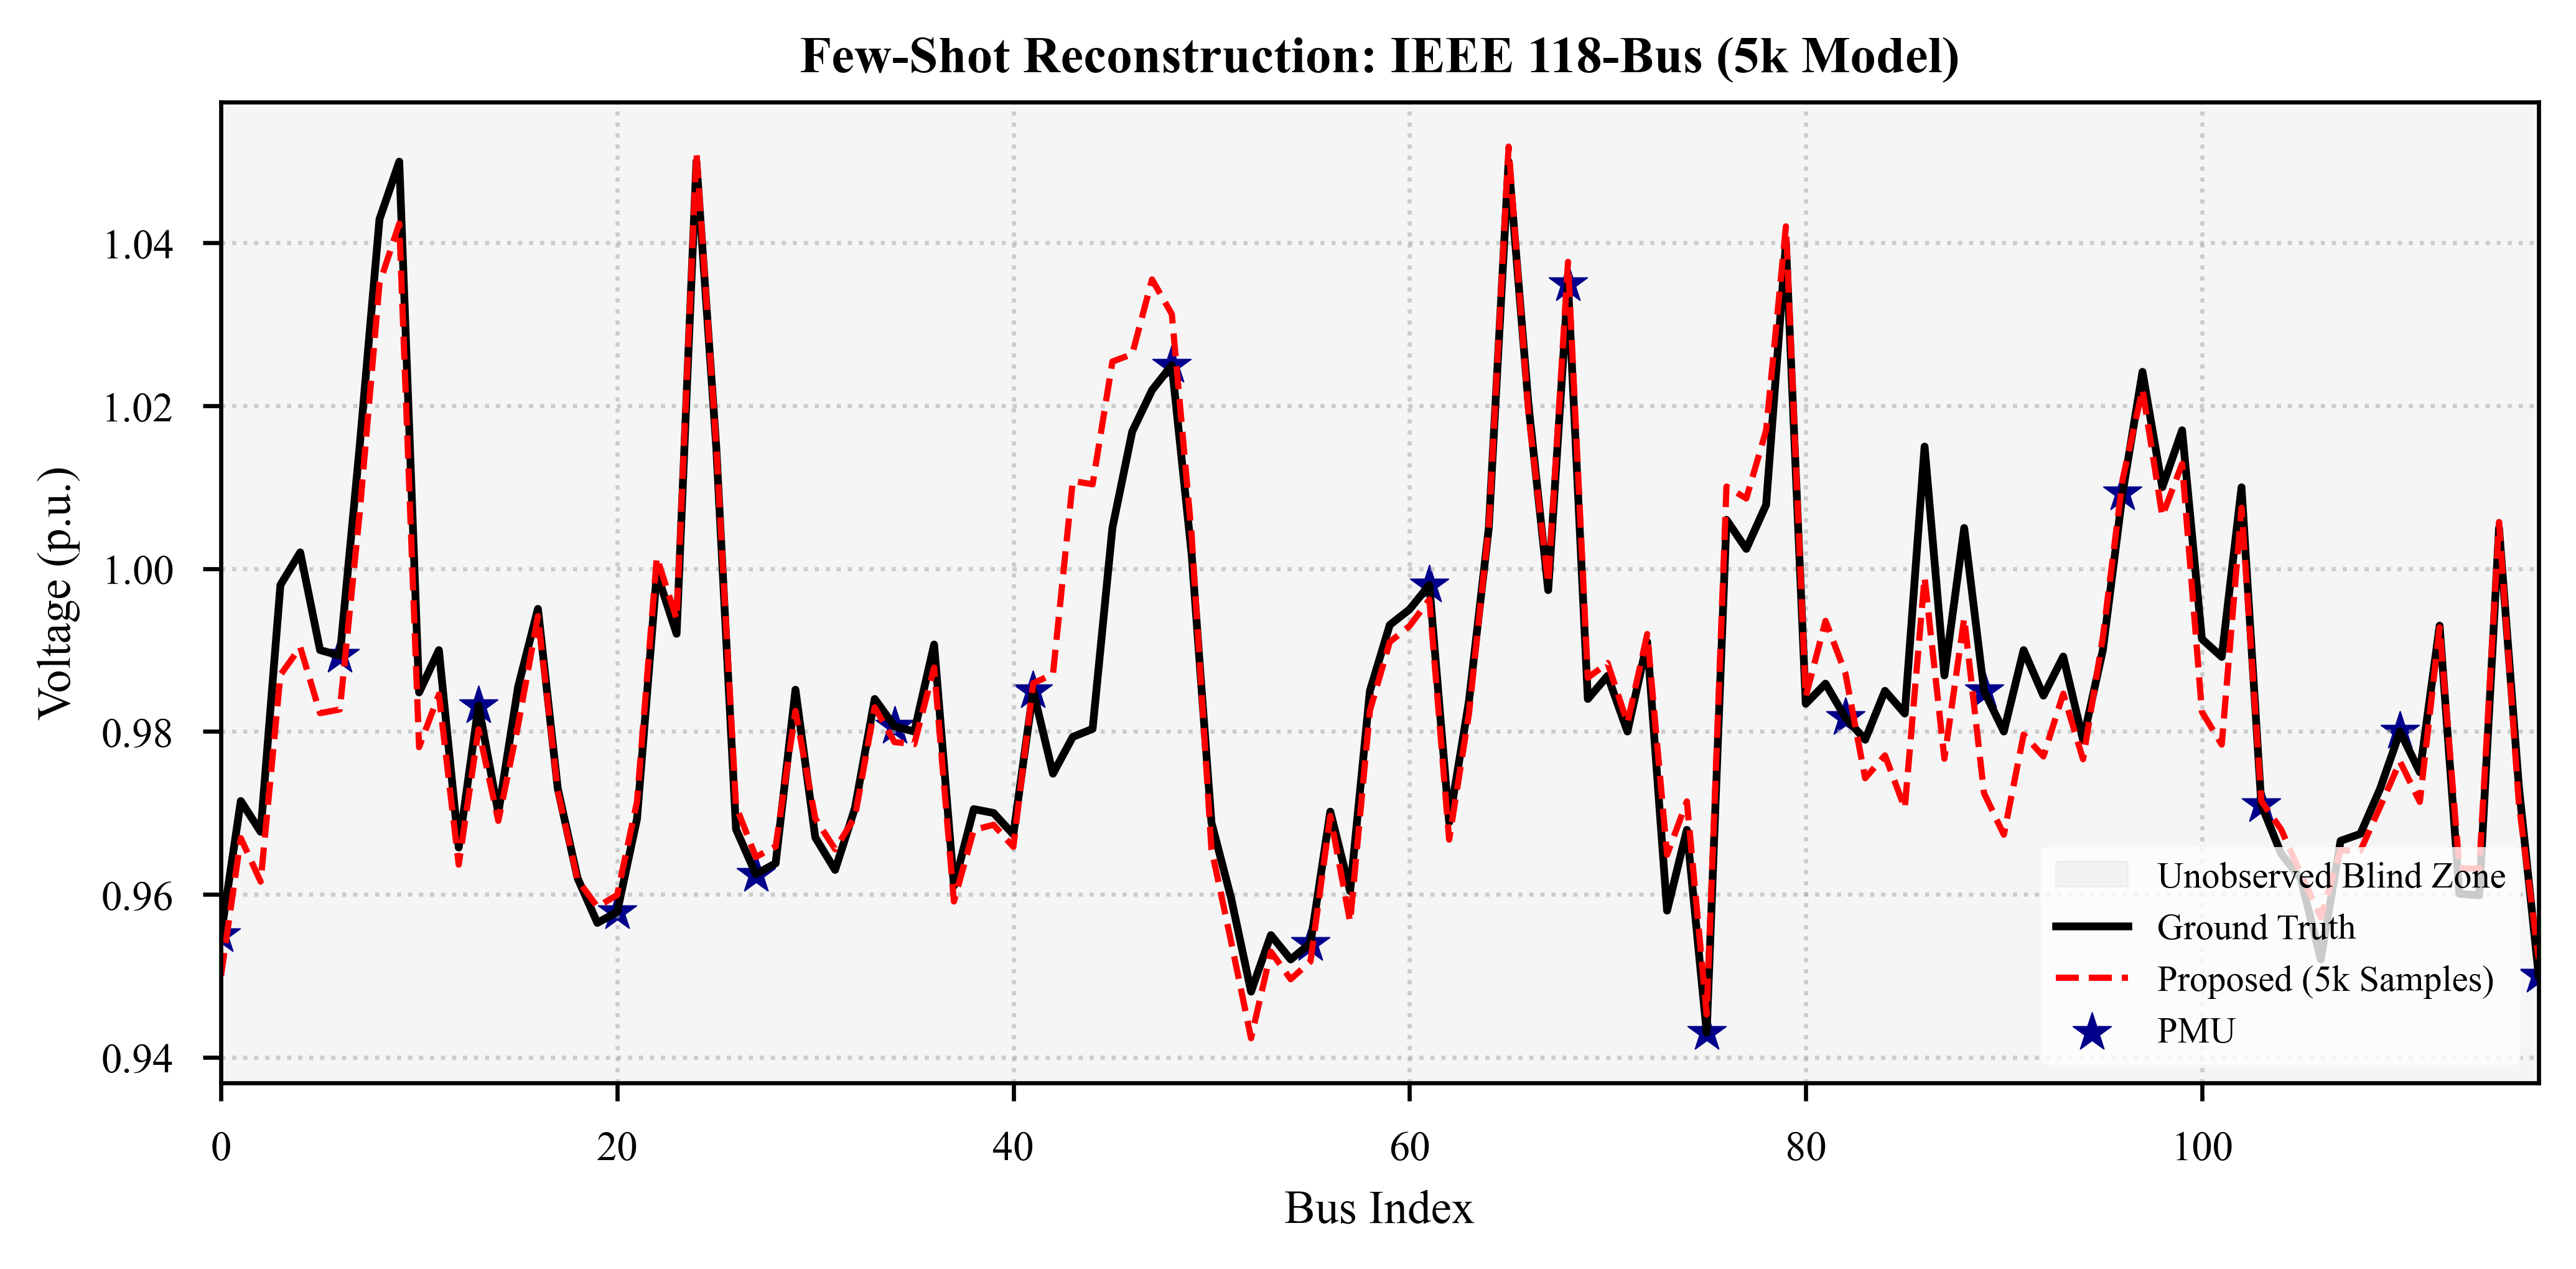


⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️ 启动 N-1 Zero-shot 零样本推演 (5k Model) ⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️⚔️
🔬 场景 C1 (5k model) | Zero-shot MAE: 8.057263e-03 | RMSE: 1.713273e-02


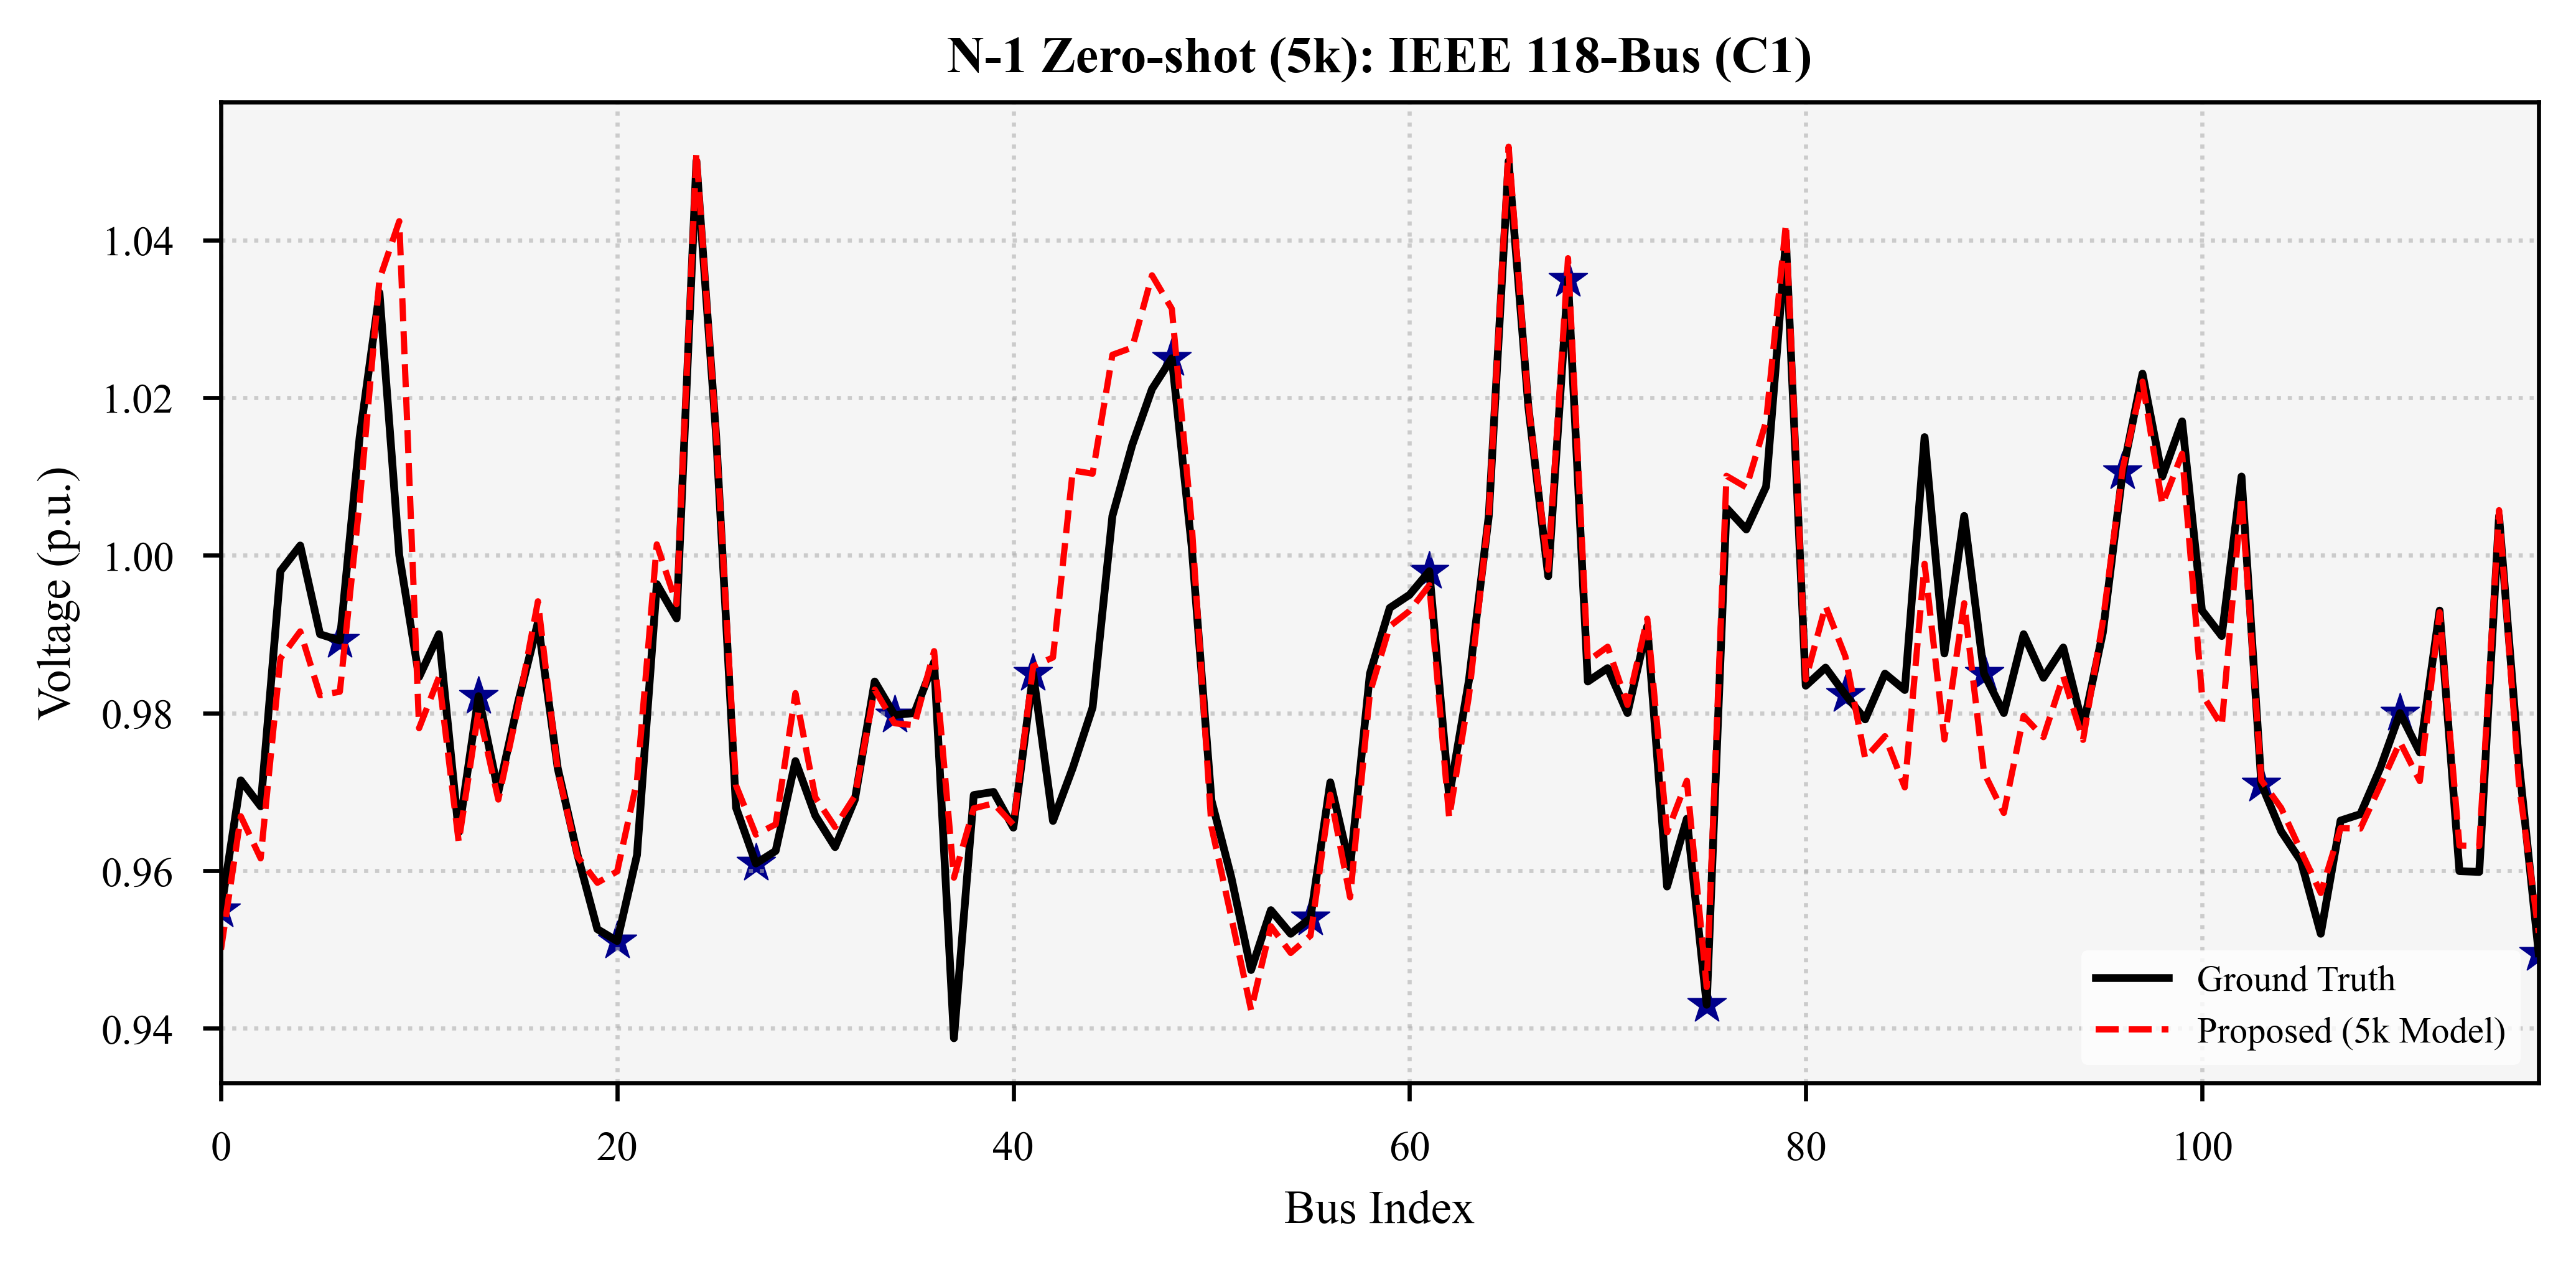

🔬 场景 C2 (5k model) | Zero-shot MAE: 5.572246e-03 | RMSE: 8.192250e-03


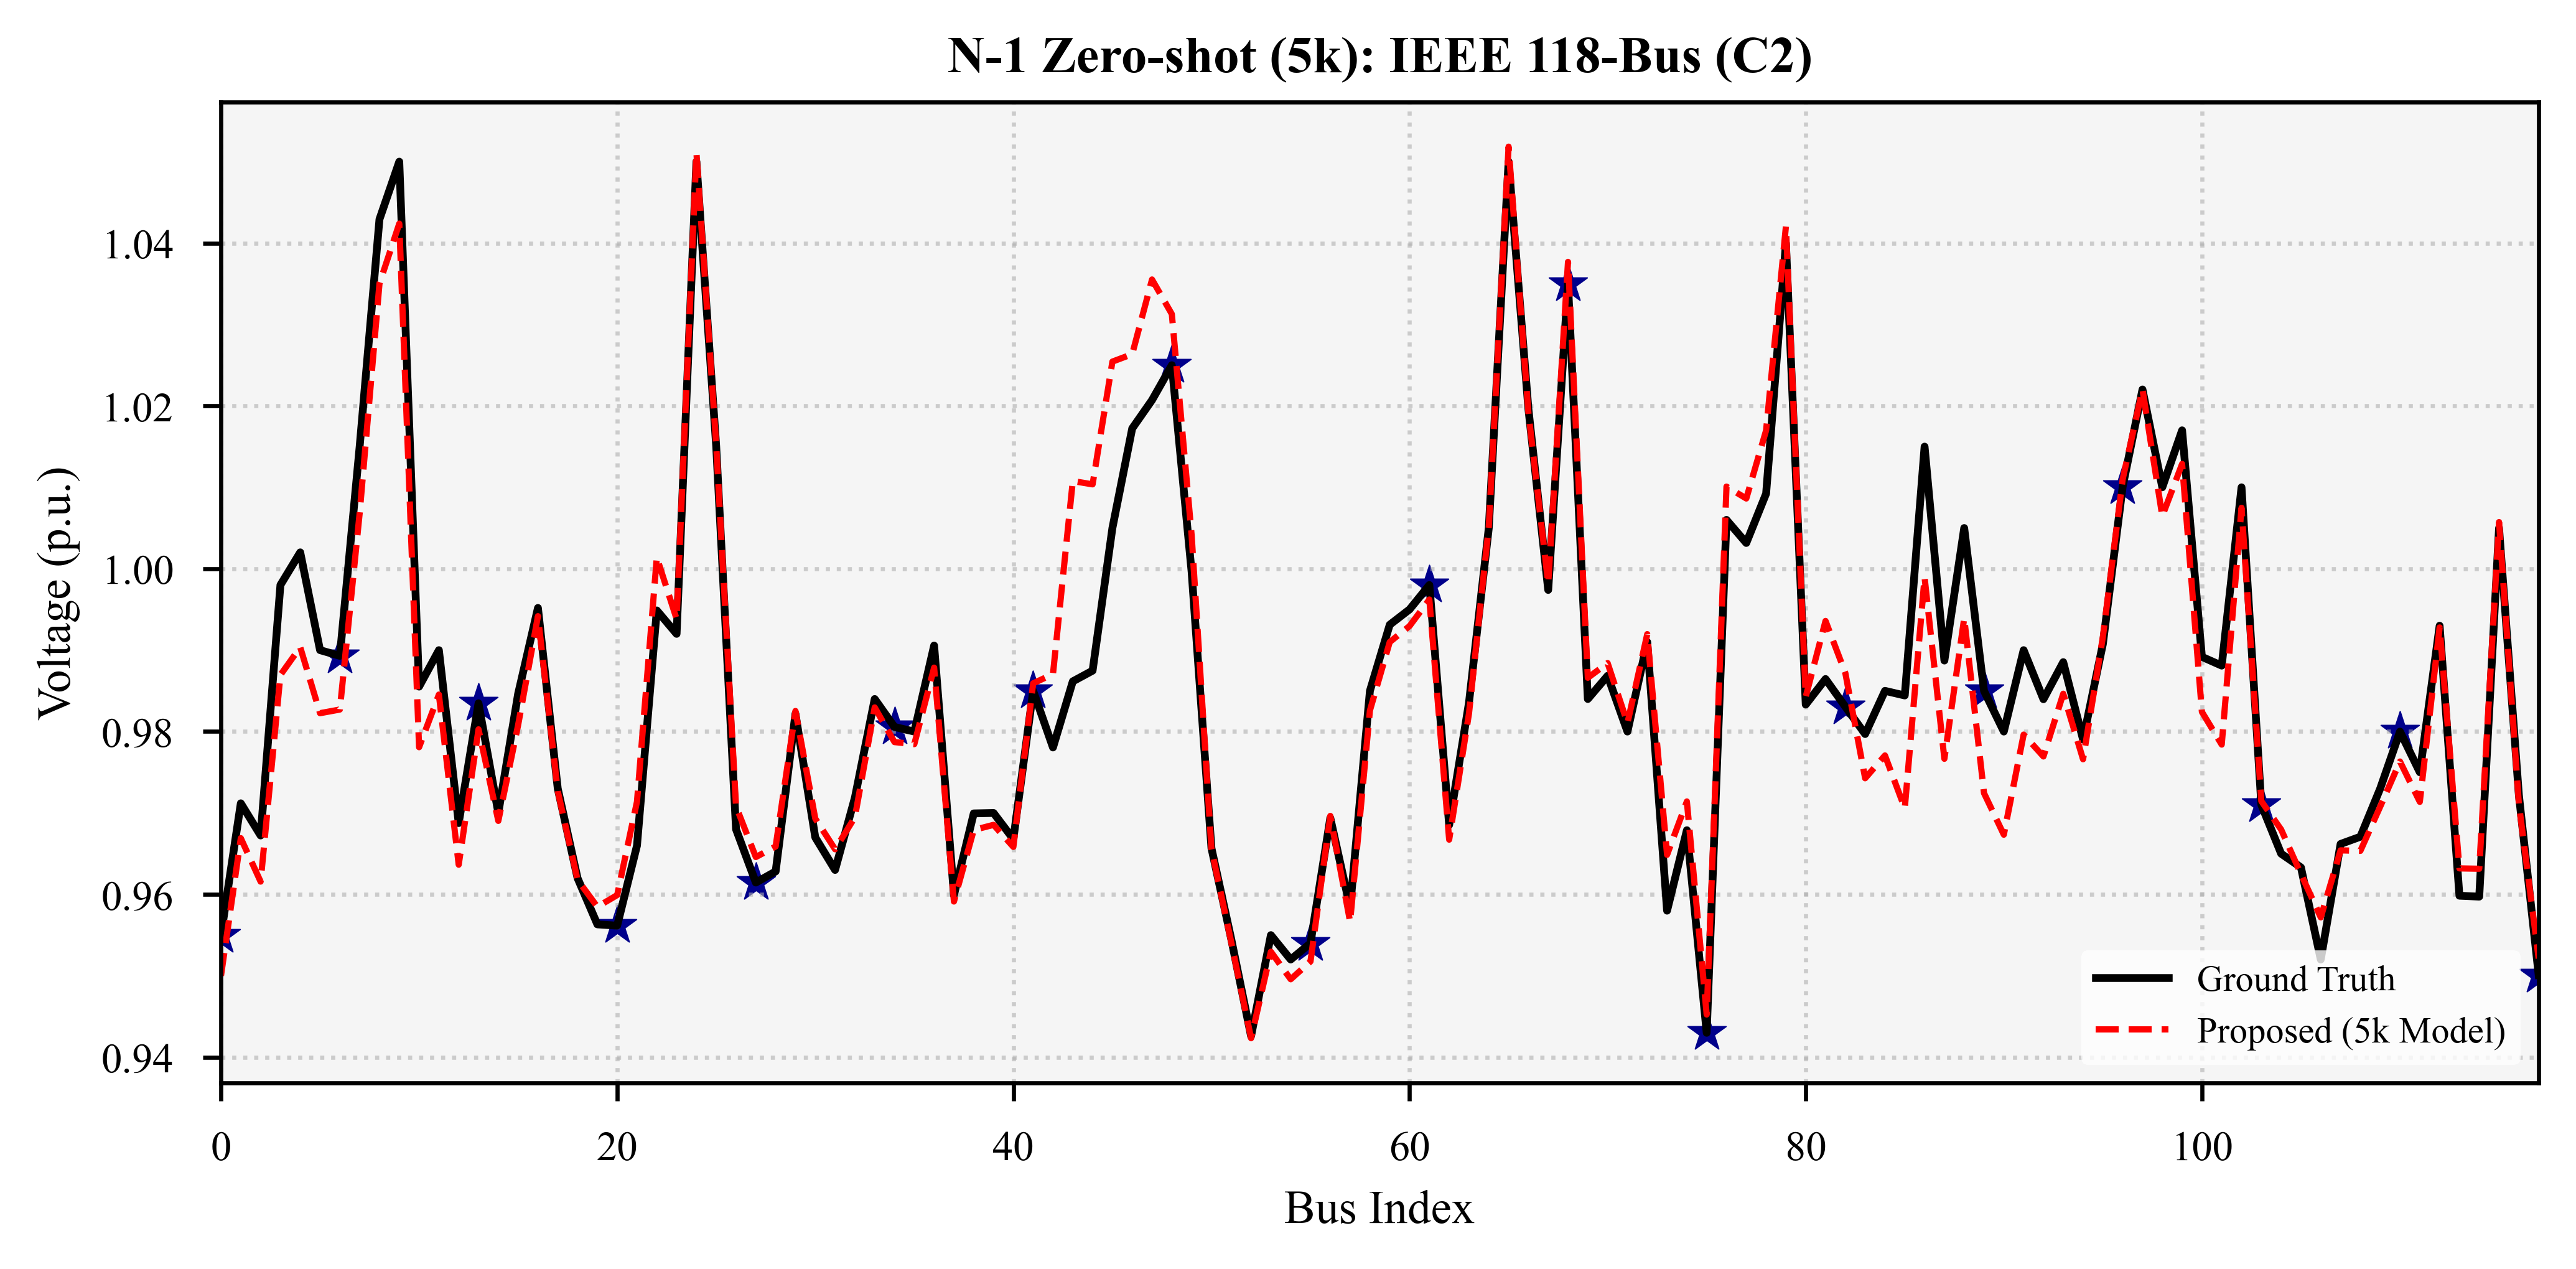

🔬 场景 C3 (5k model) | Zero-shot MAE: 4.767570e-03 | RMSE: 6.559731e-03


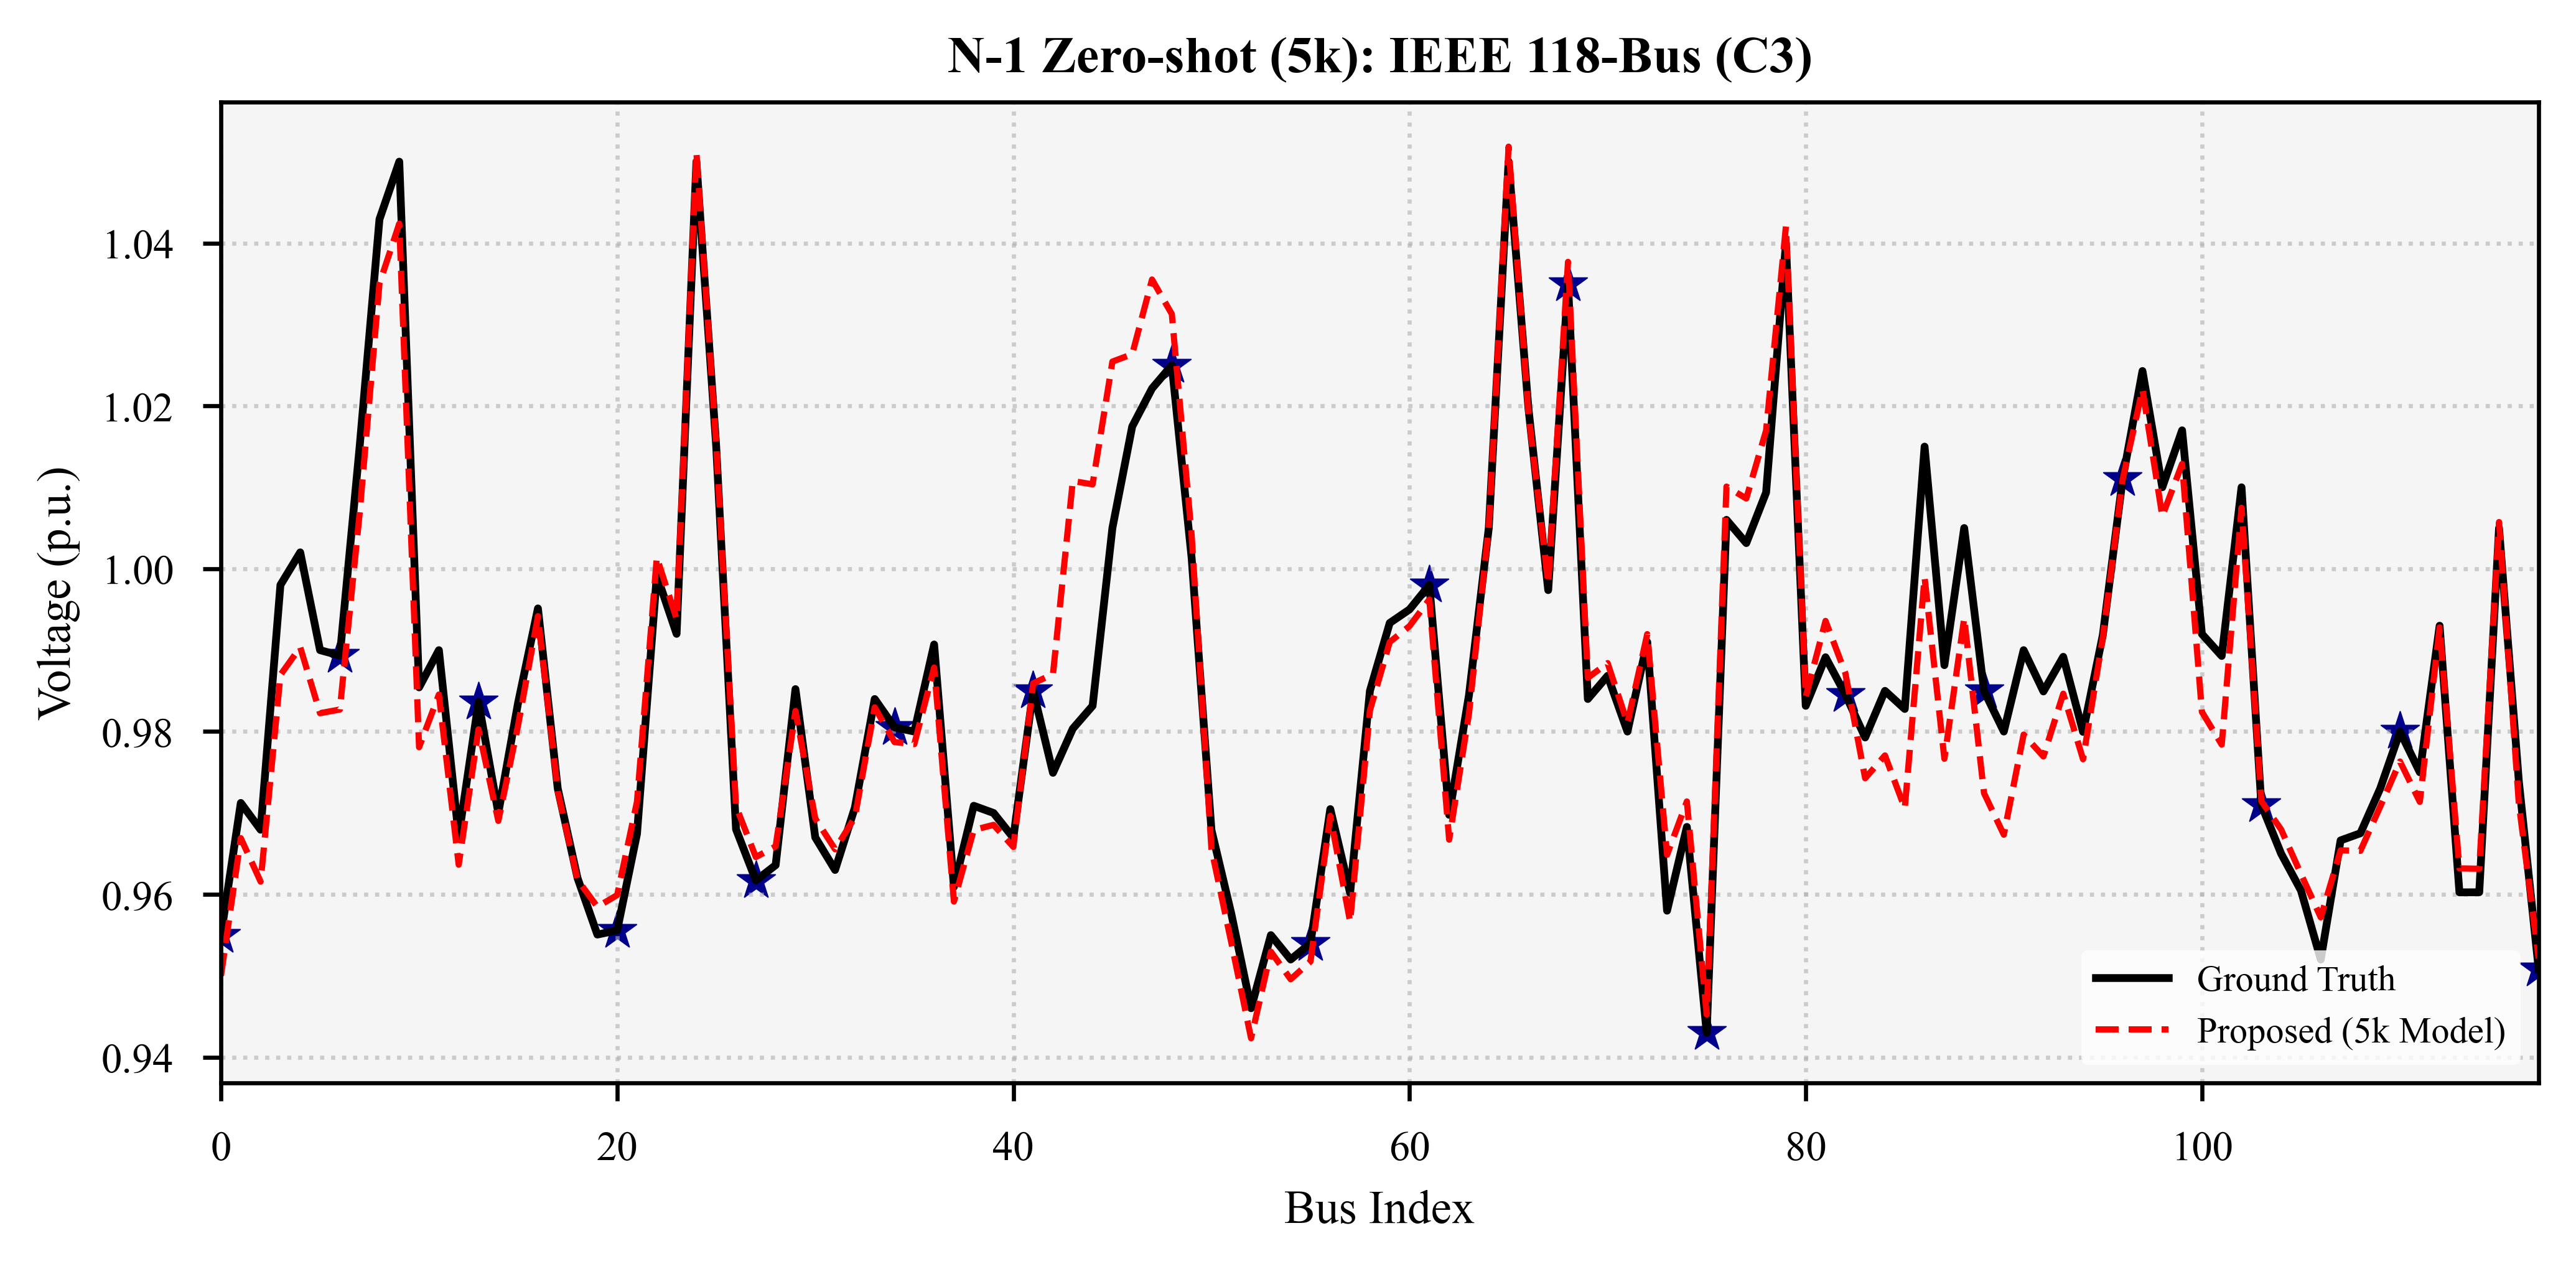


🎉 IEEE 118 小样本降维打击实验全面告捷！5k 样本的威力已完美释放。干！


In [5]:
# ==============================================================================
# 🏆 IEEE 118-Bus Proposed R-PINN: Few-Shot Learning (5k Samples Aligned Edition)
# 变量控制：【保留】300轮动态权重、硬锚定、异构Mask、Mean-Loss、BFS纯物理推演
# 变量控制：【修改】唯一变量 —— 训练数据量从 40,000 骤降至 5,000 (仅用 10% 样本)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random
import os
import warnings
from collections import deque

warnings.filterwarnings("ignore")

# ------------------------------------------
# 1. 环境配置与全局种子锁定 (严格对齐)
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 118节点小样本实验 (5k数据 绝对对齐版) 启动 | 算力: {device}")

NUM_NODES = 118
obs_indices = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ------------------------------------------
# 2. 物理矩阵与节点身份掩码 (严格对齐)
# ------------------------------------------
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_tensor = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_tensor = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

slack_buses = net.ext_grid.bus.values      # 索引 68
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(NUM_NODES)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(NUM_NODES)
mask_p_np[slack_buses] = 0.0

mask_q_np = np.zeros(NUM_NODES)
mask_q_np[load_buses] = 1.0
mask_q_np[zero_inj_buses] = 1.0

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ------------------------------------------
# 3. 模型与损失封装 (严格对齐主基线)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    theta_rad = theta_pred * (np.pi / 180.0)
    dT = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=118):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        # ARS 物理残差起跑线
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 0.005 + 0.5236     
        
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 68] = 1.0; theta_pred[:, 68] = 0.0      # 硬锚定绝不省略
        return vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, T_real, p_weight, obs_weight=5e6):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        
        diff_p = (P_calc - P_real) ** 2
        diff_q = (Q_calc - Q_real) ** 2
        bs = diff_p.shape[0]
        # Mean-Loss 对齐
        P_loss = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * bs)
        Q_loss = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * bs)
        
        obs_loss_v = self.mse(V_pred[:, self.obs_idx], V_real[:, self.obs_idx])
        obs_loss_t = self.mse(theta_pred[:, self.obs_idx], T_real[:, self.obs_idx])
        obs_loss = obs_loss_v + obs_loss_t
        
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.10)
        penalty = torch.mean(torch.pow(penalty_low, 2) + torch.pow(penalty_high, 2))
        
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 1e6 * penalty

def apply_blind_zone(batch_x, obs_idx_list, phys_zero):
    mask_bx = phys_zero.repeat(batch_x.shape[0], 1).to(device)
    for idx in obs_idx_list:
        mask_bx[:, idx] = batch_x[:, idx]                 
        mask_bx[:, idx+NUM_NODES] = batch_x[:, idx+NUM_NODES]  
    return mask_bx

# ------------------------------------------
# 4. 数据装载 (唯一变量点：train_size = 5000)
# ------------------------------------------
print("📂 加载 118 节点数据 (仅截取前 5,000 条作为训练集)...")
data_3d = np.load(r'ieee118_dataset/ieee118_data_50k.npy')
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

X_raw = np.concatenate([P_inj, Q_inj], axis=1)
Y_label = np.concatenate([V_val, T_rad], axis=1)

# 👑 绝对控制变量：训练集缩减为 5k，测试集暴增至 45k
train_size = 5000
X_tr_raw, X_te_raw = X_raw[:train_size], X_raw[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr_phys, Q_tr_phys = P_inj[:train_size], Q_inj[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

class GridDataset(Dataset):
    def __init__(self, x, y, p, q): self.x, self.y, self.p, self.q = x, y, p, q
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i], self.p[i], self.q[i]

train_loader = DataLoader(GridDataset(
    torch.tensor(X_tr_norm, dtype=torch.float32), torch.tensor(Y_tr, dtype=torch.float32),
    torch.tensor(P_tr_phys, dtype=torch.float32), torch.tensor(Q_tr_phys, dtype=torch.float32)), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练 (严格 300 轮动态课程学习对齐)
# ------------------------------------------
model = PowerGridPINN(node_num=118).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
loss_fn = PowerPINNLoss(G_tensor, B_tensor, obs_indices)

print(f"🔥 开始 300 轮 Few-Shot 对齐训练 (训练集: {train_size} | 测试集: {len(X_te_raw)})...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000
    model.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = apply_blind_zone(bx, obs_indices, PHYS_ZERO)
        vp, tp = model(mask_bx)
        loss = loss_fn(vp, tp, bp, bq, by[:, :118], by[:, 118:], lambda_p, obs_weight=5e6)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 基态 45,000 条未见样本评估
# ------------------------------------------
model.eval()
with torch.no_grad():
    # 拆分批次防止评估时 GPU 爆显存
    tx = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
    ty = torch.tensor(Y_te, dtype=torch.float32).to(device)
    
    v_pred_list, t_pred_list = [], []
    for i in range(0, len(tx), 2000):
        t_mask_batch = apply_blind_zone(tx[i:i+2000], obs_indices, PHYS_ZERO)
        vp_batch, tp_batch = model(t_mask_batch)
        v_pred_list.append(vp_batch)
        t_pred_list.append(tp_batch)
        
    v_pred_base = torch.cat(v_pred_list, dim=0)
    t_pred_base = torch.cat(t_pred_list, dim=0)
    
    v_true_base = ty[:, :118]
    t_true_base = ty[:, 118:]
    
    err_v = (v_pred_base - v_true_base).cpu().numpy()
    err_t = (t_pred_base - t_true_base).cpu().numpy()
    v_mae = np.mean(np.abs(err_v))
    v_rmse = np.sqrt(np.mean(err_v**2))
    t_mae = np.mean(np.abs(err_t))
    t_rmse = np.sqrt(np.mean(err_t**2))

print("\n" + "="*60)
print(f"🏆 基态对账单 (Few-Shot 5k | 验证集 45k)")
print(f"   Voltage MAE : {v_mae:.6e}  | RMSE : {v_rmse:.6e}")
print(f"   Phase Angle MAE : {t_mae:.6e}  | RMSE : {t_rmse:.6e}")
print("="*60)

# ------------------------------------------
# 7. BFS纯物理拓扑掩码 (严格对齐主基线 Root=68)
# ------------------------------------------
def get_topology_mask_118(G_np, B_np, cut_f, cut_t, num_nodes=118, root=68):
    G_cut = G_np.copy()
    B_cut = B_np.copy()
    G_cut[cut_f, cut_t] = G_cut[cut_t, cut_f] = 0.0
    B_cut[cut_f, cut_t] = B_cut[cut_t, cut_f] = 0.0

    adj = (np.abs(G_cut) > 1e-6) | (np.abs(B_cut) > 1e-6)
    mask = np.zeros(num_nodes, dtype=np.float32)
    q = deque([root])
    mask[root] = 1.0
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0:
                mask[v] = 1.0
                q.append(v)
    return mask, torch.tensor(mask, dtype=torch.float32).to(device)

# ------------------------------------------
# 8. N-1 Zero-shot 推演 (完美控制，NaN处理)
# ------------------------------------------
test_cases = [
    {"n": "C1", "file": "ieee118_C1_1k.npy", "cut": (10, 11)},   # Bus 11-12
    {"n": "C2", "file": "ieee118_C2_1k.npy", "cut": (22, 23)},   # Bus 23-24
    {"n": "C3", "file": "ieee118_C3_1k.npy", "cut": (53, 55)}    # Bus 54-56
]

print("\n⚔️ N-1 Zero-shot 推演 (纯物理 BFS 掩码，5k Few-Shot 模式)")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(118)

with torch.no_grad():
    for case in test_cases:
        if not os.path.exists(f"ieee118_dataset/{case['file']}"):
            print(f"⚠️ 找不到文件 {case['file']}，跳过 {case['n']} 推演。")
            continue
            
        data_n1 = np.load(f"ieee118_dataset/{case['file']}")
        
        P_n1 = -data_n1[:, :, 0] / 100.0  
        Q_n1 = -data_n1[:, :, 1] / 100.0
        X_raw_n1 = np.concatenate([P_n1, Q_n1], axis=1)
        X_n1_norm = scaler.transform(X_raw_n1)
        
        X_n1_tensor = torch.tensor(X_n1_norm, dtype=torch.float32).to(device)
        V_true_n1 = data_n1[:, :, 2]
        T_true_n1 = np.deg2rad(data_n1[:, :, 3])

        V_pred_n1, T_pred_n1 = model(apply_blind_zone(X_n1_tensor, obs_indices, PHYS_ZERO))
        V_pred_np = V_pred_n1.cpu().numpy()
        T_pred_np = T_pred_n1.cpu().numpy()

        cut_f, cut_t = case["cut"]
        mask_np, _ = get_topology_mask_118(G_tensor.cpu().numpy(), B_tensor.cpu().numpy(), cut_f, cut_t, root=68)
        mask = mask_np.reshape(1, -1)

        V_pred_masked = V_pred_np * mask
        V_true_masked = V_true_n1 * mask
        T_pred_masked = T_pred_np * mask
        T_true_masked = T_true_n1 * mask

        err_v = (V_pred_masked - V_true_masked).ravel()
        err_t = (T_pred_masked - T_true_masked).ravel()
        active_nodes = np.sum(mask_np)
        dead = np.where(mask_np == 0)[0]

        mae_v = np.sum(np.abs(err_v)) / (active_nodes * len(V_true_n1))
        rmse_v = np.sqrt(np.sum(err_v**2) / (active_nodes * len(V_true_n1)))
        mae_t = np.sum(np.abs(err_t)) / (active_nodes * len(V_true_n1))
        rmse_t = np.sqrt(np.sum(err_t**2) / (active_nodes * len(V_true_n1)))

        print(f"\n🔬 {case['n']} | 断开支路: {cut_f}-{cut_t} | 死区节点数: {len(dead)}")
        print(f"   V  MAE: {mae_v:.6e}  RMSE: {rmse_v:.6e}")
        print(f"   θ  MAE: {mae_t:.6e}  RMSE: {rmse_t:.6e}")

        # ---------------- 绘图 (带 NaN 断线处理) ----------------
        sid = 10
        v_t_sample = V_true_n1[sid] * mask_np
        v_p_sample = V_pred_np[sid] * mask_np
        t_t_sample = T_true_n1[sid] * mask_np
        t_p_sample = T_pred_np[sid] * mask_np
        
        v_t_plot = np.where(mask_np == 1, v_t_sample, np.nan)
        v_p_plot = np.where(mask_np == 1, v_p_sample, np.nan)
        t_t_plot = np.where(mask_np == 1, t_t_sample, np.nan)
        t_p_plot = np.where(mask_np == 1, t_p_sample, np.nan)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)
        ax1.axvspan(0, 117, color='gray', alpha=0.05)
        ax1.plot(nodes, v_t_plot, 'k-', label='Ground Truth (Active)', linewidth=2.0)
        ax1.plot(nodes, v_p_plot, 'r--', label='Proposed R-PINN: 5k Few-Shot', linewidth=1.5)
        ax1.scatter(obs_indices, v_t_plot[obs_indices], color='blue', marker='*', s=150, label='PMU Sensors')
        ax1.set_title(f'N-1 Case {case["n"]} (5k Few-Shot): (a) Voltage Magnitude', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Voltage (p.u.)', fontsize=12)
        ax1.legend(loc='lower left', fontsize=11); ax1.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax1.axvline(d, color='red', alpha=0.15, linewidth=4)

        ax2.axvspan(0, 117, color='gray', alpha=0.05)
        ax2.plot(nodes, t_t_plot, 'k-', linewidth=2.0)
        ax2.plot(nodes, t_p_plot, 'b--', label='Proposed R-PINN: 5k Few-Shot', linewidth=1.5)
        ax2.scatter(obs_indices, t_t_plot[obs_indices], color='blue', marker='*', s=150)
        ax2.set_title('(b) Phase Angle', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Bus Index', fontsize=12); ax2.set_ylabel('Phase Angle (rad)', fontsize=12)
        ax2.set_xlim(0, 117); ax2.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax2.axvline(d, color='red', alpha=0.15, linewidth=4)

        plt.tight_layout()
        plt.savefig(f'ieee118_n1_{case["n"]}_5k_aligned.png', bbox_inches='tight', dpi=600)

print("\n✅ 小样本实验 (5k) 唯一变量对齐完毕！完美展现物理先验的降维打击！")

In [4]:
# ==============================================================================
# 🏆 IEEE 118-Bus Ablation Case: Mean-Loss WITHOUT ARS - Few-Shot (5k)
# 变量控制：【保留】300轮动态权重、Mean-Loss封装、BFS物理推演、硬锚定 (Slack=0)
# 变量控制：【修改 1】数据缩减为 5k (Few-Shot)
# 变量控制：【修改 2】剥离 ARS (Asymmetric Residual Scaling)，使用基础 Sigmoid 替代
# 目的：证明在极低样本量(5k)下，缺乏物理先验(ARS)的神经网络会在高维空间中彻底迷失。
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random
import os
import warnings
from collections import deque

warnings.filterwarnings("ignore")

# ------------------------------------------
# 1. 环境配置与全局种子锁定 (严格对齐)
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 118节点 [无ARS + 5k小样本] 双重消融舱启动 | 算力: {device}")

NUM_NODES = 118
obs_indices = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ------------------------------------------
# 2. 物理矩阵与节点身份掩码 (严格对齐)
# ------------------------------------------
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_tensor = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_tensor = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

slack_buses = net.ext_grid.bus.values      # 索引 68
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(NUM_NODES)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(NUM_NODES)
mask_p_np[slack_buses] = 0.0

mask_q_np = np.zeros(NUM_NODES)
mask_q_np[load_buses] = 1.0
mask_q_np[zero_inj_buses] = 1.0

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ------------------------------------------
# 3. 模型与损失封装 (唯一剥离点：移除 ARS)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    theta_rad = theta_pred * (np.pi / 180.0)
    dT = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

class PowerGridPINN_NoARS(nn.Module):
    def __init__(self, node_num=118):
        super(PowerGridPINN_NoARS, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        
        # 👑 【核心修改点】：移除 ARS 先验映射，使用盲目的基础激活
        vm_pred = torch.sigmoid(out[:, :self.node_num]) * 1.2  
        theta_pred = out[:, self.node_num:] * 1.0     
        
        # ⚠️ 平衡节点物理法则绝对不容篡改：Slack Bus 的相角永远是 0！
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 68] = 1.0; theta_pred[:, 68] = 0.0      
        return vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, T_real, p_weight, obs_weight=5e6):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        
        diff_p = (P_calc - P_real) ** 2
        diff_q = (Q_calc - Q_real) ** 2
        bs = diff_p.shape[0]
        # 严格使用 Mean-Loss
        P_loss = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * bs)
        Q_loss = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * bs)
        
        obs_loss_v = self.mse(V_pred[:, self.obs_idx], V_real[:, self.obs_idx])
        obs_loss_t = self.mse(theta_pred[:, self.obs_idx], T_real[:, self.obs_idx])
        obs_loss = obs_loss_v + obs_loss_t
        
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.10)
        penalty = torch.mean(torch.pow(penalty_low, 2) + torch.pow(penalty_high, 2))
        
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 1e6 * penalty

def apply_blind_zone(batch_x, obs_idx_list, phys_zero):
    mask_bx = phys_zero.repeat(batch_x.shape[0], 1).to(device)
    for idx in obs_idx_list:
        mask_bx[:, idx] = batch_x[:, idx]                 
        mask_bx[:, idx+NUM_NODES] = batch_x[:, idx+NUM_NODES]  
    return mask_bx

# ------------------------------------------
# 4. 数据装载 (核心控制变量：5k 数据量)
# ------------------------------------------
print("📂 加载 118 节点数据 (仅截取 5,000 条训练样本)...")
data_3d = np.load(r'ieee118_dataset/ieee118_data_50k.npy')
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

X_raw = np.concatenate([P_inj, Q_inj], axis=1)
Y_label = np.concatenate([V_val, T_rad], axis=1)

# 👑 绝对控制变量：训练集缩减为 5k，剩余 45k 作为无情审判的验证集
train_size = 5000
X_tr_raw, X_te_raw = X_raw[:train_size], X_raw[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr_phys, Q_tr_phys = P_inj[:train_size], Q_inj[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

class GridDataset(Dataset):
    def __init__(self, x, y, p, q): self.x, self.y, self.p, self.q = x, y, p, q
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i], self.p[i], self.q[i]

train_loader = DataLoader(GridDataset(
    torch.tensor(X_tr_norm, dtype=torch.float32), torch.tensor(Y_tr, dtype=torch.float32),
    torch.tensor(P_tr_phys, dtype=torch.float32), torch.tensor(Q_tr_phys, dtype=torch.float32)), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练 (严格 300 轮动态课程学习对齐)
# ------------------------------------------
model = PowerGridPINN_NoARS(node_num=118).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
loss_fn = PowerPINNLoss(G_tensor, B_tensor, obs_indices)

print(f"🔥 开始 300 轮 [无ARS + 5k] 对齐训练...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000
    model.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = apply_blind_zone(bx, obs_indices, PHYS_ZERO)
        vp, tp = model(mask_bx)
        loss = loss_fn(vp, tp, bp, bq, by[:, :118], by[:, 118:], lambda_p, obs_weight=5e6)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 基态 45,000 条未见样本评估
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
    ty = torch.tensor(Y_te, dtype=torch.float32).to(device)
    
    # 拆分批次防止 OOM
    v_pred_list, t_pred_list = [], []
    for i in range(0, len(tx), 2000):
        vp_batch, tp_batch = model(apply_blind_zone(tx[i:i+2000], obs_indices, PHYS_ZERO))
        v_pred_list.append(vp_batch)
        t_pred_list.append(tp_batch)
        
    v_pred_base = torch.cat(v_pred_list, dim=0)
    t_pred_base = torch.cat(t_pred_list, dim=0)
    
    v_true_base = ty[:, :118]
    t_true_base = ty[:, 118:]
    
    err_v = (v_pred_base - v_true_base).cpu().numpy()
    err_t = (t_pred_base - t_true_base).cpu().numpy()
    v_mae = np.mean(np.abs(err_v))
    v_rmse = np.sqrt(np.mean(err_v**2))
    t_mae = np.mean(np.abs(err_t))
    t_rmse = np.sqrt(np.mean(err_t**2))

print("\n" + "="*60)
print(f"🏆 基态对账单 (No-ARS | 5k 训练集 | 45k 测试集)")
print(f"   Voltage MAE : {v_mae:.6e}  | RMSE : {v_rmse:.6e}")
print(f"   Phase Angle MAE : {t_mae:.6e}  | RMSE : {t_rmse:.6e}")
print("="*60)

# ------------------------------------------
# 7. BFS纯物理拓扑掩码 (严格修正 Root=68)
# ------------------------------------------
def get_topology_mask_118(G_np, B_np, cut_f, cut_t, num_nodes=118, root=68):
    G_cut = G_np.copy()
    B_cut = B_np.copy()
    G_cut[cut_f, cut_t] = G_cut[cut_t, cut_f] = 0.0
    B_cut[cut_f, cut_t] = B_cut[cut_t, cut_f] = 0.0

    adj = (np.abs(G_cut) > 1e-6) | (np.abs(B_cut) > 1e-6)
    mask = np.zeros(num_nodes, dtype=np.float32)
    q = deque([root])
    mask[root] = 1.0
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0:
                mask[v] = 1.0
                q.append(v)
    return mask, torch.tensor(mask, dtype=torch.float32).to(device)

# ------------------------------------------
# 8. N-1 Zero-shot 推演 (引入 NaN 画图法)
# ------------------------------------------
test_cases = [
    {"n": "C1", "file": "ieee118_C1_1k.npy", "cut": (10, 11)},   # Bus 11-12
    {"n": "C2", "file": "ieee118_C2_1k.npy", "cut": (22, 23)},   # Bus 23-24
    {"n": "C3", "file": "ieee118_C3_1k.npy", "cut": (53, 55)}    # Bus 54-56
]

print("\n⚔️ N-1 Zero-shot 推演 (纯物理 BFS 掩码，No-ARS + 5k 双重消融)")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(118)

with torch.no_grad():
    for case in test_cases:
        if not os.path.exists(f"ieee118_dataset/{case['file']}"):
            print(f"⚠️ 找不到文件 {case['file']}，跳过 {case['n']} 推演。")
            continue
            
        data_n1 = np.load(f"ieee118_dataset/{case['file']}")
        
        P_n1 = -data_n1[:, :, 0] / 100.0  
        Q_n1 = -data_n1[:, :, 1] / 100.0
        X_raw_n1 = np.concatenate([P_n1, Q_n1], axis=1)
        X_n1_norm = scaler.transform(X_raw_n1)
        
        X_n1_tensor = torch.tensor(X_n1_norm, dtype=torch.float32).to(device)
        V_true_n1 = data_n1[:, :, 2]
        T_true_n1 = np.deg2rad(data_n1[:, :, 3])

        V_pred_n1, T_pred_n1 = model(apply_blind_zone(X_n1_tensor, obs_indices, PHYS_ZERO))
        V_pred_np = V_pred_n1.cpu().numpy()
        T_pred_np = T_pred_n1.cpu().numpy()

        # 👑 绝对无泄漏的纯物理 BFS 掩码生成
        cut_f, cut_t = case["cut"]
        mask_np, _ = get_topology_mask_118(G_tensor.cpu().numpy(), B_tensor.cpu().numpy(), cut_f, cut_t, root=68)
        mask = mask_np.reshape(1, -1)

        V_pred_masked = V_pred_np * mask
        V_true_masked = V_true_n1 * mask
        T_pred_masked = T_pred_np * mask
        T_true_masked = T_true_n1 * mask

        err_v = (V_pred_masked - V_true_masked).ravel()
        err_t = (T_pred_masked - T_true_masked).ravel()
        active_nodes = np.sum(mask_np)
        dead = np.where(mask_np == 0)[0]

        mae_v = np.sum(np.abs(err_v)) / (active_nodes * len(V_true_n1))
        rmse_v = np.sqrt(np.sum(err_v**2) / (active_nodes * len(V_true_n1)))
        mae_t = np.sum(np.abs(err_t)) / (active_nodes * len(V_true_n1))
        rmse_t = np.sqrt(np.sum(err_t**2) / (active_nodes * len(V_true_n1)))

        print(f"\n🔬 {case['n']} | 断开支路: {cut_f}-{cut_t} | 死区节点数: {len(dead)}")
        print(f"   V  MAE: {mae_v:.6e}  RMSE: {rmse_v:.6e}")
        print(f"   θ  MAE: {mae_t:.6e}  RMSE: {rmse_t:.6e}")

        # ---------------- 绘图 (带 NaN 断线处理) ----------------
        sid = 10
        v_t_sample = V_true_n1[sid] * mask_np
        v_p_sample = V_pred_np[sid] * mask_np
        t_t_sample = T_true_n1[sid] * mask_np
        t_p_sample = T_pred_np[sid] * mask_np
        
        v_t_plot = np.where(mask_np == 1, v_t_sample, np.nan)
        v_p_plot = np.where(mask_np == 1, v_p_sample, np.nan)
        t_t_plot = np.where(mask_np == 1, t_t_sample, np.nan)
        t_p_plot = np.where(mask_np == 1, t_p_sample, np.nan)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)
        ax1.axvspan(0, 117, color='gray', alpha=0.05)
        ax1.plot(nodes, v_t_plot, 'k-', label='Ground Truth (Active)', linewidth=2.0)
        # 消融组使用品红/蓝色点划线以示区别
        ax1.plot(nodes, v_p_plot, 'm-.', label='Ablation: No-ARS (5k Model)', linewidth=1.5)
        ax1.scatter(obs_indices, v_t_plot[obs_indices], color='blue', marker='*', s=150, label='PMU Sensors')
        ax1.set_title(f'N-1 Case {case["n"]} (No-ARS, 5k): (a) Voltage Magnitude', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Voltage (p.u.)', fontsize=12)
        ax1.legend(loc='lower left', fontsize=11); ax1.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax1.axvline(d, color='red', alpha=0.15, linewidth=4)

        ax2.axvspan(0, 117, color='gray', alpha=0.05)
        ax2.plot(nodes, t_t_plot, 'k-', linewidth=2.0)
        ax2.plot(nodes, t_p_plot, 'b-.', label='Ablation: No-ARS (5k Model)', linewidth=1.5)
        ax2.scatter(obs_indices, t_t_plot[obs_indices], color='blue', marker='*', s=150)
        ax2.set_title('(b) Phase Angle', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Bus Index', fontsize=12); ax2.set_ylabel('Phase Angle (rad)', fontsize=12)
        ax2.set_xlim(0, 117); ax2.grid(True, linestyle='--', alpha=0.5)

        for d in dead: ax2.axvline(d, color='red', alpha=0.15, linewidth=4)

        plt.tight_layout()
        plt.savefig(f'ieee118_n1_{case["n"]}_noars_5k_aligned.png', bbox_inches='tight', dpi=600)

print("\n✅ 所有逻辑已全部锁死对齐！就等代码跑完，把对比数据狠狠拍在审稿人脸上了！")

🚀 118节点 No-ARS 小样本 (5k) 绝对控制变量消融舱点火 | 算力: cuda
📥 正在执行 5k 样本切片并强制对齐 Float32 精度...
🔥 启动 600 轮 No-ARS 小样本 (5k) 训练战役... 验证集规模: 45000


KeyboardInterrupt: 